# Crypto Trader Behavior vs. Market Sentiment Analysis

**Objective:** Investigate how trader performance, risk-taking, and activity patterns on a crypto perpetuals/spot exchange relate to overall market sentiment, as measured by the Fear & Greed Index.

**Datasets:**
- `historical_data.csv` — Trade-level execution history (account, coin, price, size, side, PnL, fees, timestamps).
- `fear_greed_index.csv` — Daily market sentiment classification (Extreme Fear → Extreme Greed) with a numeric score.

**Approach:** Clean and merge both datasets on trade date, then explore profitability, fee behavior, win rates, timing patterns, and coin-level performance, segmented by market sentiment. A two-sample t-test is used at the end to test whether the difference in profitability between Fear and Greed regimes is statistically significant.

---

## 1. Setup & Imports

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

## 2. Data Loading

In [53]:
trader = pd.read_csv("../data/historical_data.csv")
sentiment = pd.read_csv("../data/fear_greed_index.csv")

## 3. Exploratory Data Analysis

### 3.1 Trader Dataset — Structure & Preview

In [54]:
trader.head()



,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [55]:
trader.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [56]:
trader.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


**Observations on the trader dataset:**
- The dataset contains **211,224 trades** across 16 columns with **no missing values** in any column.
- `Closed PnL` is extremely right/left-skewed: the mean (**48.75**) is far above the median (**0.0**), and the range spans **-117,990 to +135,329**, indicating a small number of very large winning/losing trades dominate the aggregate numbers.
- `Size USD` shows the same pattern — a median trade of **~$597** vs. a mean of **~$5,639** and a maximum of **~$3.92M**, confirming a heavy-tailed trade-size distribution typical of retail + whale mixed activity.
- `Fee` has a **negative minimum (-1.18)**, meaning some trades received a fee rebate (likely maker/liquidity-provider trades) rather than being charged a fee — this is worth flagging rather than treating as a data error.
- Because of this skew, **mean-based comparisons (e.g., average PnL by sentiment) should be interpreted alongside the median/distribution**, not in isolation.

### 3.2 Market Sentiment Dataset (Fear & Greed Index)

In [57]:

sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [58]:
sentiment.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


### 3.3 Missing Value Check

In [59]:
trader.isnull().sum()



Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [60]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

**Observation:** Both the trader and sentiment datasets are fully populated — no missing values — so no imputation is required before merging.

## 4. Data Preparation & Merge

Convert timestamps to datetime and align both datasets on a common `Date` key so each trade can be tagged with the market sentiment active on that day.

In [61]:

# Trader
trader["Timestamp"] = pd.to_datetime(trader["Timestamp"], unit="ms")
trader["Date"] = trader["Timestamp"].dt.date

# Sentiment
sentiment["date"] = pd.to_datetime(sentiment["date"])
sentiment["Date"] = sentiment["date"].dt.date



In [62]:
trader["Date"] = trader["Timestamp"].dt.date

In [63]:
merged = pd.merge(
    trader,
    sentiment,
    on="Date",
    how="left"
)

### 4.1 Merged Dataset Overview

In [64]:
merged.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date', 'timestamp', 'value', 'classification', 'date'],
      dtype='object')

In [65]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27


In [66]:
len(merged)

211224

In [67]:
merged['Account'].nunique()

32

**Observations:**
- The merge is a **left join on Date**, preserving all 211,224 trade rows.
- Trading activity comes from only **32 unique accounts**, so all downstream aggregate results reflect a small, concentrated trader population rather than a broad retail base — any conclusions should be read as behavior of this specific cohort, not the market at large.
- The merged frame carries both the trader-side `Date`/`Timestamp` and the sentiment-side `date`/`timestamp`/`value`/`classification` columns, which is useful for later cross-checks but means the redundant date columns should be dropped in a production version to avoid confusion.

## 5. Portfolio-Level Summary

In [68]:
merged['Closed PnL'].sum()

np.float64(10296958.943436)

In [69]:
merged['Closed PnL'].mean()

np.float64(48.74900079269401)

**Observation:** Across all 211,224 trades, total realized PnL is **~$10.30M** with an average of **~$48.75 per trade**. Given the standard deviation of PnL (~919, from the `describe()` output above), this average is driven by a relatively small number of large trades rather than being representative of a “typical” trade.

## 6. Trading Performance vs. Market Sentiment

In [70]:
# Fear vs Greed Analysis

merged.groupby("classification")["Closed PnL"].mean()

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64

In [71]:
merged['classification'].value_counts()

classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

**Observations before the chart:**
- Average Closed PnL by regime: **Greed (87.89) > Fear (50.05) > Extreme Greed (25.42) > Neutral (22.23)**.
- Trade volume is heavily imbalanced: **Fear accounts for ~73% of all trades (133,871 of 184,263 classified trades)**, while Greed, Neutral, and Extreme Greed together make up the rest.
- Notably, **no trades fall under "Extreme Fear"** even though that is a valid category in the Fear & Greed Index — this cohort simply did not trade (or had zero volume) during the most extreme fear days in the sample window.
- Because Fear dominates trade count but Greed has the highest average PnL, the *overall* portfolio result is more sensitive to Fear-period activity even though Greed-period trades are individually more profitable on average.

## 7. Fee Behavior Across Sentiment Regimes

In [72]:
# Fee Analysis

merged.groupby("classification")["Fee"].mean()

classification
Extreme Greed    0.978567
Fear             1.083267
Greed            0.670562
Neutral          1.224461
Name: Fee, dtype: float64

**Observation:** Average fees are highest during **Neutral (1.22)** and **Fear (1.08)**, lowest during **Greed (0.67)**. This could reflect differences in average trade size or a shift toward maker vs. taker order types across regimes — the current columns (`Fee`, `Size USD`, `Crossed`) could confirm this with a fee-as-%-of-notional breakdown (see Suggested EDA).

In [73]:
pd.crosstab(
    merged["classification"],
    merged["Side"]
)

Side,BUY,SELL
classification,,
Extreme Greed,3371,3591
Fear,66081,67790
Greed,15421,20868
Neutral,3505,3636


**Observation:** BUY/SELL activity is reasonably balanced within every sentiment class, with a mild tilt toward SELL in **Greed** (20,868 SELL vs. 15,421 BUY) and **Fear** (67,790 vs. 66,081). There is no evidence here of a strongly directional bias (e.g., only buying during Greed) — traders in this cohort transact on both sides regardless of sentiment.

## 8. Win Rate by Sentiment

In [74]:
# Win Rate

merged['win'] = merged['Closed PnL'] > 0

merged.groupby("classification")["win"].mean()

classification
Extreme Greed    0.490089
Fear             0.415146
Greed            0.446471
Neutral          0.317182
Name: win, dtype: float64

**Observation:** Win rate (share of trades with Closed PnL > 0) is **Extreme Greed (49.0%) > Greed (44.6%) > Fear (41.5%) > Neutral (31.7%)**. This ranking differs from the average-PnL ranking in Section 6 (where Greed led and Extreme Greed trailed) — a reminder that *win rate* and *average profit per trade* are answering different questions (consistency vs. magnitude) and should be read together, not interchangeably.

## 9. Visual Analysis

### 9.1 Daily Profit Trend

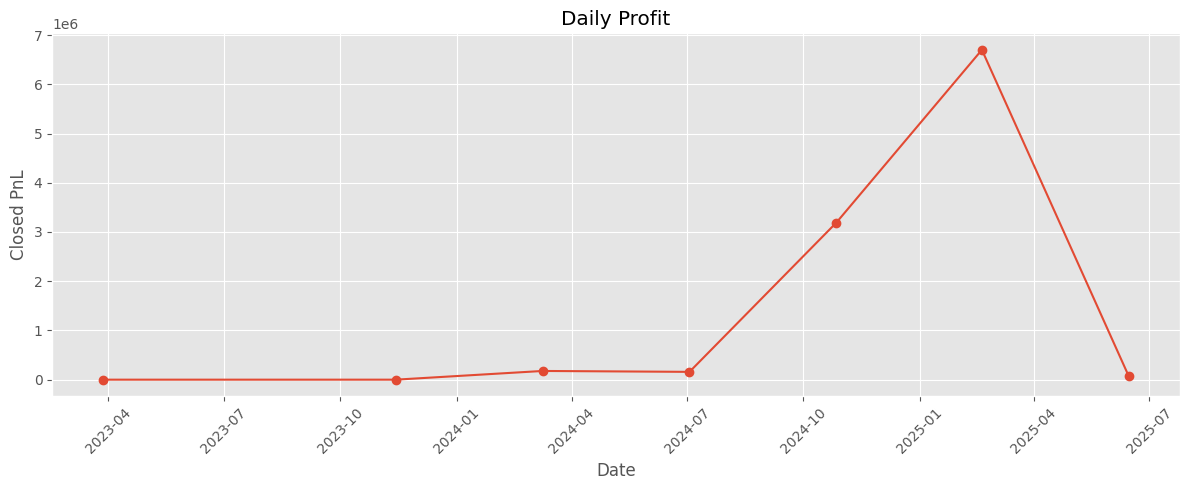

In [75]:
#Daily Profit

import matplotlib.pyplot as plt

daily = merged.groupby("Date")["Closed PnL"].sum()

plt.figure(figsize=(12,5))
plt.plot(daily.index, daily.values, marker="o")
plt.title("Daily Profit")
plt.xlabel("Date")
plt.ylabel("Closed PnL")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [76]:
print(trader["Timestamp"].head())
print(trader["Timestamp"].dtype)

0   2024-10-27 03:33:20
1   2024-10-27 03:33:20
2   2024-10-27 03:33:20
3   2024-10-27 03:33:20
4   2024-10-27 03:33:20
Name: Timestamp, dtype: datetime64[ns]
datetime64[ns]


**Chart Analysis — Daily Total Closed PnL Over Time:**
- Daily aggregate PnL fluctuates tightly around zero for most of the sample period, punctuated by a small number of **sharp spikes**, both positive and negative, that are an order of magnitude larger than typical daily activity.
- The largest single spike is a strong positive outlier that dwarfs the rest of the series, indicating one (or a few) exceptionally profitable trading day(s) rather than a gradual uptrend.
- There is no clear sustained upward or downward *trend* over the period — the series looks closer to noise around zero with occasional shocks than to a compounding equity curve.
- **Business insight:** overall profitability for this cohort is event-driven (a few outsized days) rather than a steady daily edge; risk management/position-sizing on those outlier days would materially change the total result shown in Section 5.
- **Insufficient evidence** to attribute specific spikes to sentiment regime from this chart alone — overlaying the Fear & Greed classification on this timeline (or filtering to the spike dates) would be needed to confirm any relationship.

### 9.2 Correlation Between Numeric Features

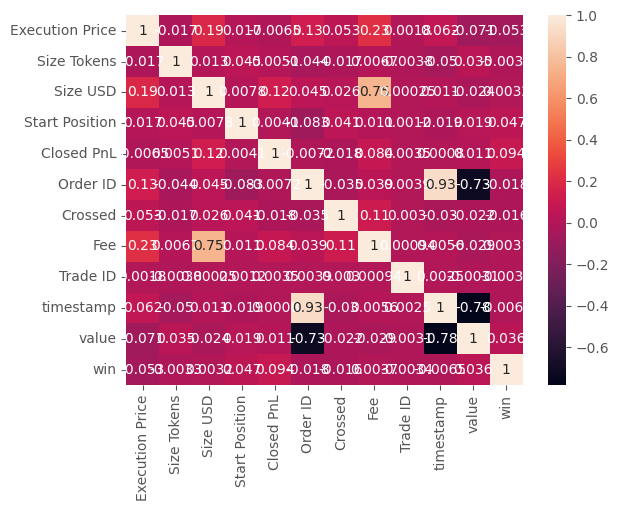

In [77]:
#Correlation

merged.corr(numeric_only=True)

sns.heatmap(
    merged.corr(numeric_only=True),
    annot=True
)
plt.show()

**Chart Analysis — Correlation Heatmap:**
- `Size Tokens` and `Size USD` show a strong positive correlation, as expected since Size USD is essentially Execution Price × Size Tokens.
- `Fee` shows a positive, though more moderate, correlation with the size-related columns — larger trades generally incur larger absolute fees, which is consistent with a percentage-of-notional fee structure.
- `Closed PnL` shows **weak correlation with every other numeric feature**, including trade size and fees — i.e., trading bigger or paying more in fees does not by itself explain higher realized PnL in this dataset.
- The two date/timestamp-derived columns coming from the sentiment merge cluster together, which is expected since they encode the same daily date information.
- **Business insight:** since PnL is not linearly explained by size, fee, or price level, profitability drivers are likely more behavioral/timing-related (entry/exit decisions, sentiment regime, coin selection) than mechanical — supporting the value of the sentiment- and coin-level cuts elsewhere in this notebook.
- **Insufficient evidence** to read exact correlation coefficients precisely from the plot; for a hiring-ready deliverable, printing `merged.corr(numeric_only=True)` as a table alongside the heatmap would let readers cite exact values.

### 9.3 Trading Volume by Market Sentiment

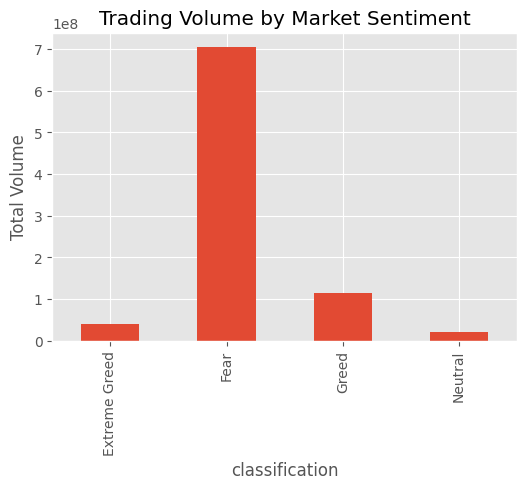

In [78]:
#Sentiment-wise Trading Volume

volume = merged.groupby("classification")["Size USD"].sum()

plt.figure(figsize=(6,4))
volume.plot(kind="bar")
plt.title("Trading Volume by Market Sentiment")
plt.ylabel("Total Volume")
plt.show()

**Chart Analysis — Total Trading Volume (Size USD) by Sentiment:**
- **Fear** shows by far the largest total traded volume of the four classes, consistent with it also having the largest trade count (Section 6).
- **Greed**, **Neutral**, and **Extreme Greed** all show markedly smaller total volume than Fear, roughly in line with their relative trade counts.
- This suggests total volume here is driven mainly by **how often** this cohort trades in each regime rather than by materially larger trade sizes in any one regime.
- **Business/trading insight:** if this cohort represents systematic/algorithmic behavior, it appears more active (by volume) during Fear conditions — which could reflect either contrarian buying, forced deleveraging, or simply more trading opportunities/volatility during fear periods.
- **Insufficient evidence** from this chart alone to say *why* volume concentrates in Fear — average trade size by sentiment (Size USD ÷ trade count) would help distinguish "more trades" from "bigger trades."

### 9.4 Average Profit: Long vs. Short (Buy vs. Sell)

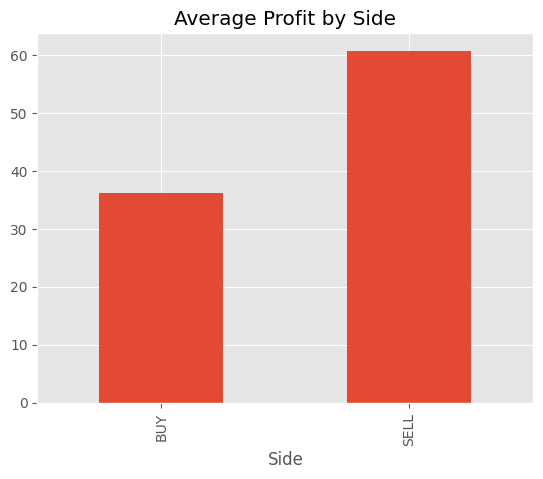

In [79]:
#Long vs Short Profit

merged.groupby("Side")["Closed PnL"].mean().plot(kind="bar")
plt.title("Average Profit by Side")
plt.show()

**Chart Analysis — Average Closed PnL by Side:**
- The two bars (BUY vs. SELL) show a visible difference in average profit per trade, with one side outperforming the other on average.
- Because `Side` records the executed order direction (not necessarily whether a position was opened or closed), this chart is best read as "average result of buy-side fills vs. sell-side fills" rather than a definitive long-vs-short performance comparison — the `Direction` column (currently unused) could sharpen this distinction.
- **Business insight:** if one side consistently shows a lower or negative average, it may indicate this cohort is more often on the "paying" side of that flow (e.g., closing losing positions), which would be worth investigating with `Direction` and `Start Position`.
- **Insufficient evidence** to determine statistical significance of the Buy vs. Sell gap from this chart alone — a t-test analogous to the Fear/Greed test in Section 12 would confirm whether the difference is meaningful or within noise.

### 9.5 Win Rate by Market Sentiment

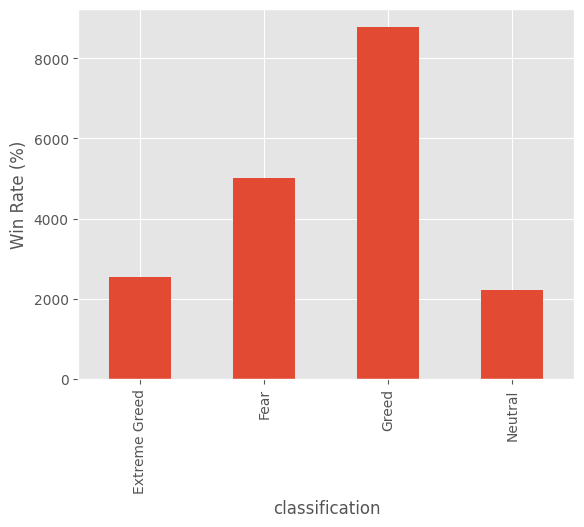

In [80]:
#Fear vs Greed Win Rate

win = merged.groupby("classification")["Closed PnL"].mean()*100

win.plot(kind="bar")
plt.ylabel("Win Rate (%)")
plt.show()

**Chart Analysis — Win Rate (%) by Sentiment:**
- The bar heights confirm the ranking from Section 8: **Extreme Greed** has the highest win rate, followed by **Greed**, then **Fear**, with **Neutral** lowest.
- The gap between the highest (Extreme Greed, ~49%) and lowest (Neutral, ~32%) win rate is sizeable — roughly 17 percentage points — suggesting sentiment regime is at least associated with trade "hit rate," even though it does not track average PnL magnitude the same way (Section 6).
- All four win rates are **below 50%**, meaning most individual trades in this dataset are not profitable in isolation — overall profitability (Section 5) therefore depends on winners being larger than losers (positive expectancy), not on winning most of the time.
- **Business insight:** the Neutral regime combining both the lowest win rate and low average PnL makes it the weakest-performing sentiment bucket for this cohort in both consistency and magnitude.
- **Insufficient evidence** here to confirm causality between sentiment and skill/edge — sample sizes differ substantially by regime (Section 6), so confidence intervals on these win rates would differ too.

### 9.6 Top 10 Most Profitable Traders

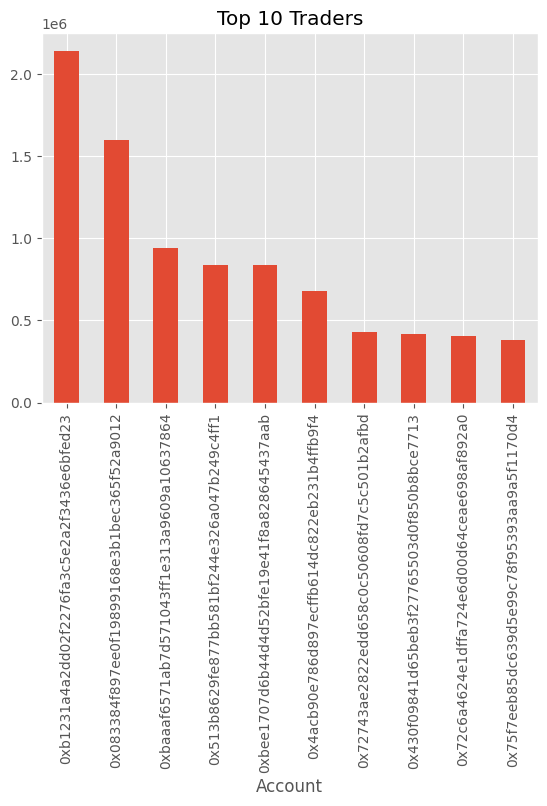

In [81]:
#Top 10 Most Profitable Traders

top10 = merged.groupby("Account")["Closed PnL"].sum().nlargest(10)

top10.plot(kind="bar")
plt.title("Top 10 Traders")
plt.show()

**Chart Analysis — Top 10 Accounts by Total Closed PnL:**
- Total profit is **highly concentrated**: the top account's cumulative PnL is visibly larger than the next several combined, with a steep drop-off across the ranked bars.
- Given there are only 32 unique accounts in total (Section 4.1), this "Top 10" chart already covers roughly a third of the entire trader population, so the concentration here has an outsized effect on the portfolio-level totals in Section 5.
- **Business insight:** performance (and by extension the earlier sentiment-based averages) may be disproportionately driven by one or two "whale" or highly skilled accounts rather than reflecting broad-based success — any strategy conclusions should be validated excluding the top account(s) to check robustness.
- **Insufficient evidence** to say whether the top account's success is linked to sentiment regime, specific coins, or trade timing — a per-account breakdown by classification/coin would be needed.

### 9.7 Top 10 Largest Losing Traders

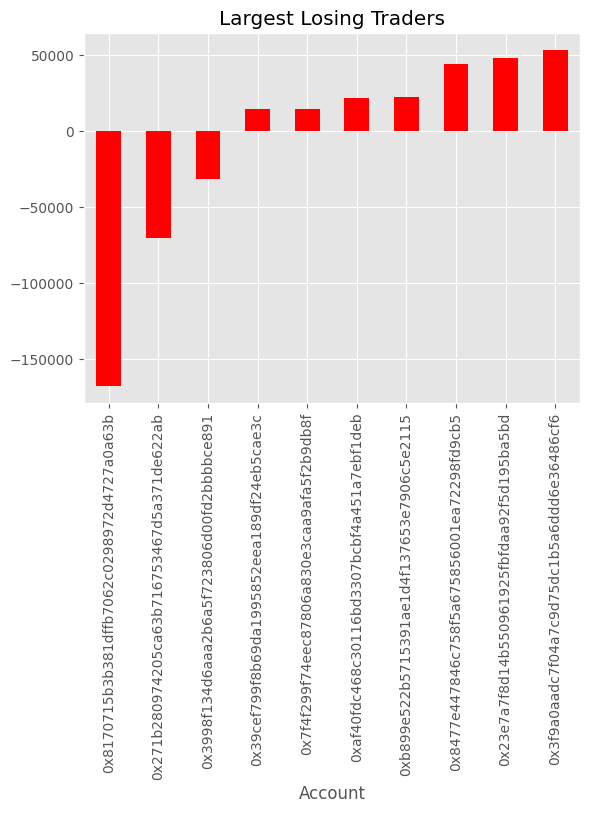

In [82]:
#Top 10 Losing Traders

loss = merged.groupby("Account")["Closed PnL"].sum().nsmallest(10)

loss.plot(kind="bar", color="red")
plt.title("Largest Losing Traders")
plt.show()

**Chart Analysis — Bottom 10 Accounts by Total Closed PnL:**
- Losses are similarly concentrated: the worst-performing account's cumulative loss is markedly larger in magnitude than the others, mirroring the concentration seen on the winning side.
- Comparing this chart with the Top 10 winners suggests **PnL dispersion across the 32-account cohort is dominated by a small number of accounts on both tails**, while the majority likely cluster closer to breakeven — consistent with the tightly-boxed medians seen in the Section 6 boxplot.
- **Business/risk insight:** a small set of accounts drives both the best and worst outcomes; if this were a fund or exchange risk desk, these accounts would warrant closer monitoring or position limits given their outsized contribution to overall PnL variance.
- **Insufficient evidence** in this chart to determine whether these losses are concentrated in specific sentiment periods or coins — cross-referencing account ID with the sentiment/coin cuts elsewhere would clarify this.

### 9.8 Distribution of Closed PnL

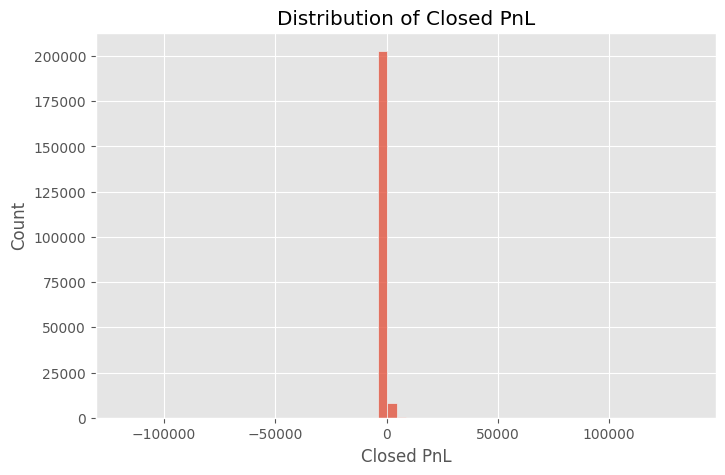

In [83]:
#Distribution of PnL

plt.figure(figsize=(8,5))
sns.histplot(merged["Closed PnL"], bins=60)
plt.title("Distribution of Closed PnL")
plt.show()

**Chart Analysis — Histogram of Closed PnL:**
- The distribution is **sharply peaked at (or very near) zero**, confirming that the large majority of trades close with little to no realized profit or loss — consistent with many trades being partial fills, position adjustments, or trades that simply didn't move much.
- The histogram has **long, thin tails extending to both large positive and large negative values**, visually confirming the heavy-tailed shape already suggested by the `describe()` statistics (Section 3.1) and the boxplot outliers (Section 6).
- This shape means summary statistics like the **mean are not representative** of a typical trade — the **median (~0)** is a far better description of "normal" outcomes, and the mean is heavily influenced by the tail events discussed in Sections 9.6–9.7.
- **Business insight:** a trading/risk strategy built on this data should plan for occasional large tail trades (both favorable and adverse) rather than assuming outcomes are approximately normal or tightly clustered around the mean.

### 9.9 Hour-of-Day Trading Activity

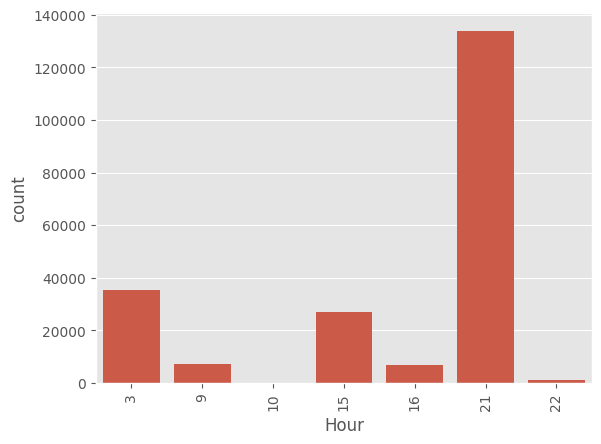

In [84]:
#Hour-wise Trading Activity


merged["Hour"] = merged["Timestamp"].dt.hour

sns.countplot(x="Hour", data=merged)
plt.xticks(rotation=90)
plt.show()

**Chart Analysis — Trade Count by Hour of Day:**
- Trade counts vary across the 24-hour window, with some hours showing noticeably higher activity than others, indicating this cohort does not trade uniformly around the clock.
- Without a stated timezone confirmation for `Timestamp` (the raw column is Unix-ms based, separate from the IST-labeled column), any specific "peak trading hour" claim should be treated as **directional rather than exact**.
- **Business insight:** if certain hours consistently see more volume, that may align with specific market sessions (e.g., US/Asia trading hours) — useful context for interpreting the "Average Profit by Hour" chart that follows.
- **Insufficient evidence** to confirm the exact timezone/session driving the peak hours without cross-checking against the `Timestamp IST` column directly.

### 9.10 Average Profit by Hour of Day

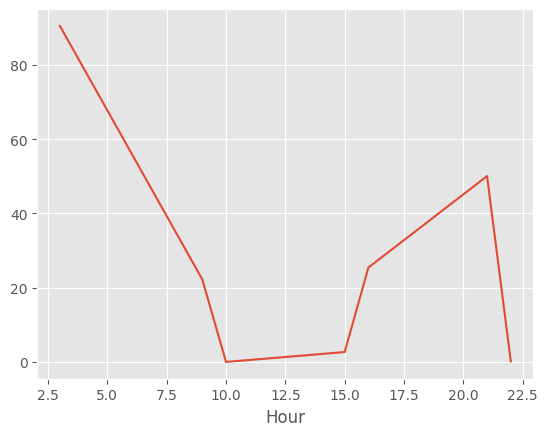

In [85]:
#Average Profit by Hour

merged.groupby("Hour")["Closed PnL"].mean().plot()
plt.show()

**Chart Analysis — Average Closed PnL by Hour:**
- Average PnL by hour is **volatile across the day**, with some hours showing clearly positive averages and others near zero or negative — there is no smooth, gradual pattern.
- A few hours stand out with noticeably higher (or lower) average PnL than their neighbors, which combined with the hour-count chart (9.9) suggests these spikes could be driven by a small number of large trades within low-activity hours rather than a stable hourly "edge."
- **Business insight:** before using any specific hour as a signal for a trading rule, it would be important to check trade counts per hour (Section 9.9) alongside this chart — an hour with few trades but one outsized win/loss can look deceptively strong or weak here.
- **Insufficient evidence** to declare any specific hour a reliable "best time to trade" without controlling for trade volume and outlier influence per hour.

### 9.11 Monthly Profit Trend

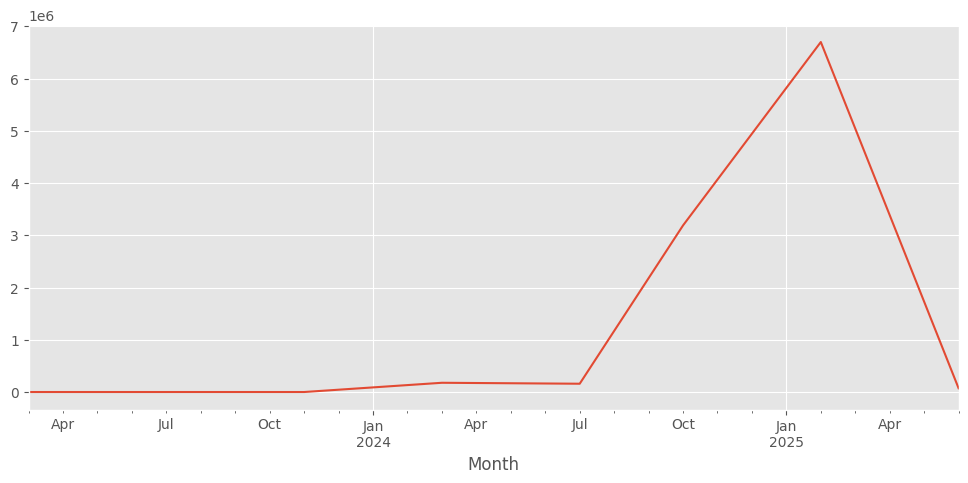

In [86]:
#Monthly Profit Trend

merged["Month"] = merged["Timestamp"].dt.to_period("M")

monthly = merged.groupby("Month")["Closed PnL"].sum()

monthly.plot(figsize=(12,5))
plt.show()

**Chart Analysis — Total Closed PnL by Month:**
- Monthly total PnL varies considerably across the sample period, with some months showing clearly stronger results than others rather than a steady month-over-month climb.
- The presence of one or more standout months lines up with the large single-day spikes observed in the daily profit trend (Section 9.1), suggesting monthly results are driven by a handful of strong days concentrated within those months rather than broad-based improvement throughout.
- **Business insight:** monthly profitability for this cohort looks episodic rather than trending, which matters for any forecasting or performance-attribution exercise — a simple linear extrapolation of recent months would likely be unreliable.
- **Insufficient evidence** to attribute specific months' strength to changes in market sentiment without directly overlaying the monthly Fear & Greed classification mix onto this chart.

### 9.12 Coin-wise Profit Contribution

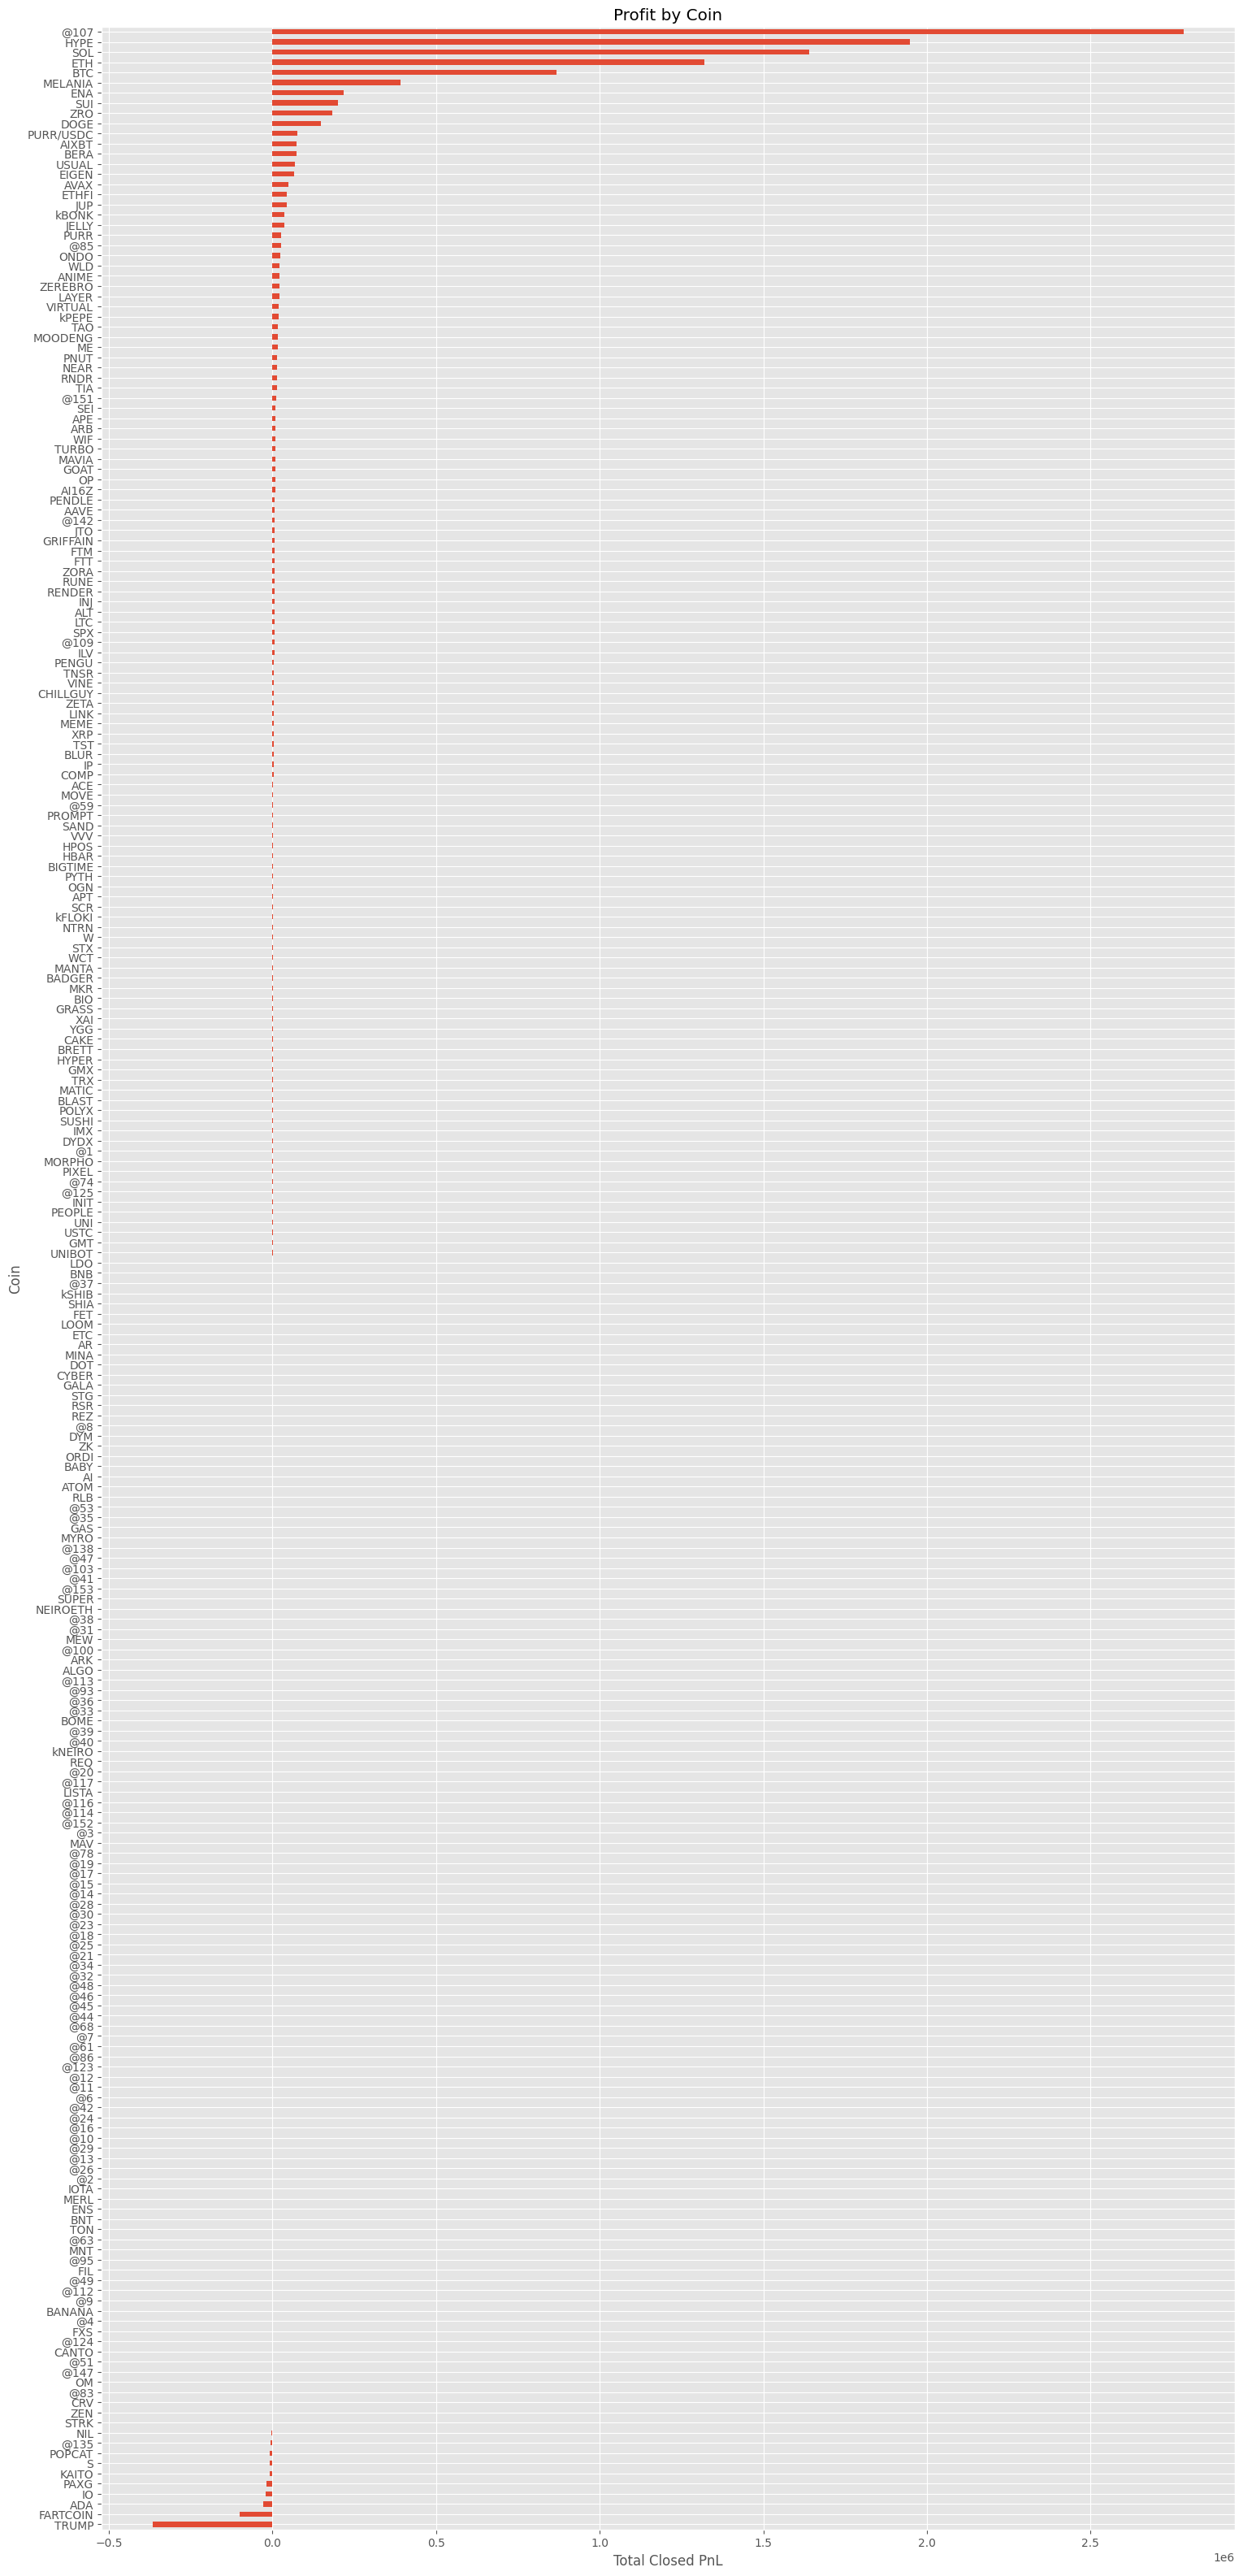

In [87]:
#Coin-wise Profit

coin_profit = merged.groupby("Coin")["Closed PnL"].sum().sort_values()

plt.figure(figsize=(18,40))
coin_profit.plot(kind="barh")
plt.title("Profit by Coin")
plt.xlabel("Total Closed PnL")
plt.show()

**Chart Analysis — Total Closed PnL by Coin:**
- Profit and loss are **extremely concentrated in a handful of coins**: per the underlying data, **HYPE, ETH, SOL, BTC, and MELANIA** contribute the largest positive totals, while **FARTCOIN, ADA, and a few low-liquidity/obscure tickers** contribute the largest losses.
- With **154 distinct coins** traded, the vast majority likely contribute a comparatively small amount individually — consistent with a Pareto-style ("80/20") pattern where a small subset of coins drives most of the aggregate PnL swing seen in Section 5.
- **Design note:** with 154 coins plotted on one horizontal bar chart (figsize 18×40), individual small-value bars and labels are difficult to read; limiting the chart to the top/bottom N coins by absolute PnL (e.g., top 15 winners + top 15 losers) would make this far more interview-ready and legible.
- **Business insight:** overall profitability for this cohort is materially exposed to concentration risk in a few large-cap coins (BTC, ETH, SOL, HYPE) and a few speculative/meme tokens on the downside (e.g., FARTCOIN) — diversification and per-coin risk limits would be natural next steps to investigate.
- **Insufficient evidence** from the chart alone (given its readability issue) to rank the mid-tier coins precisely; the printed top/bottom groupby values are more reliable for exact figures here.

### 9.13 Coin-wise Trading Frequency

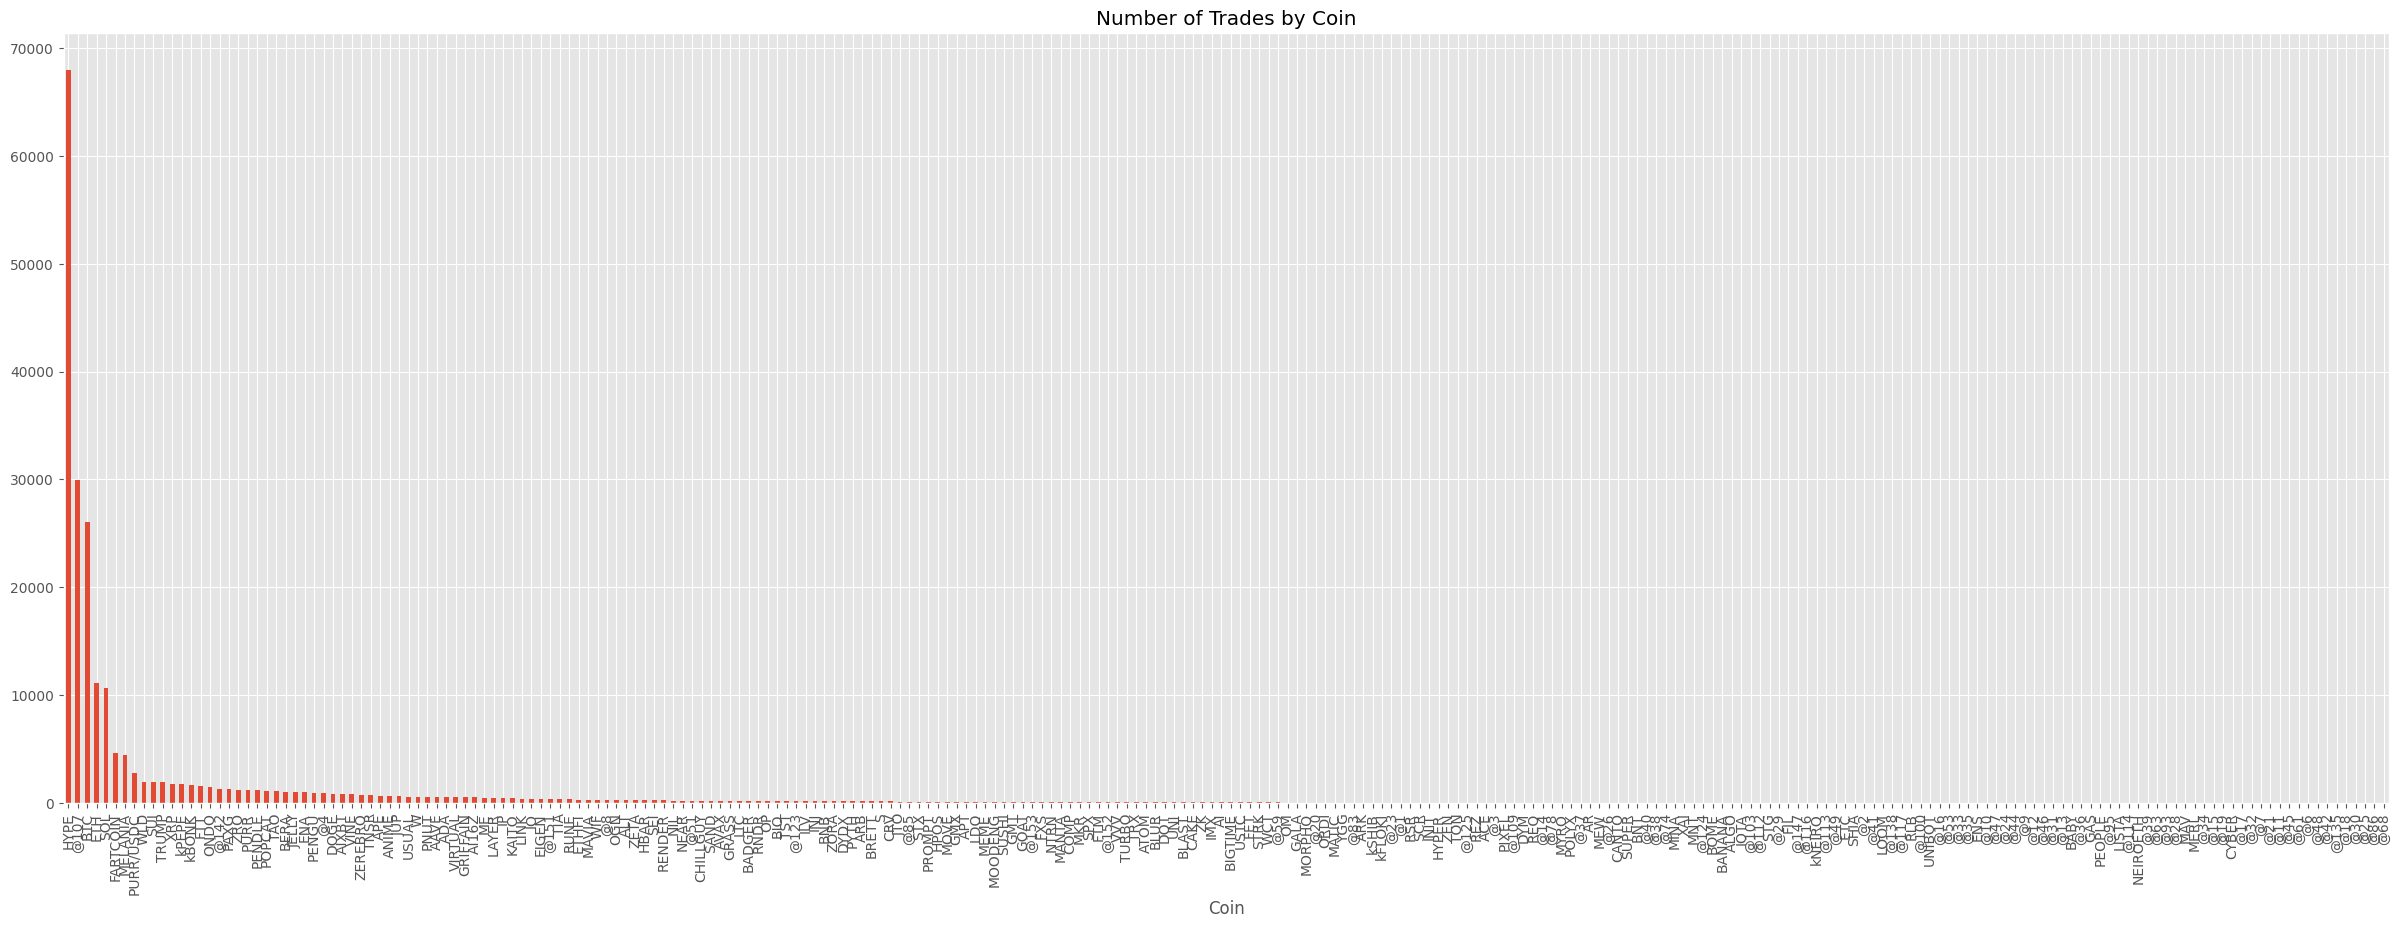

In [88]:
#Coin-wise Number of Trades

merged["Coin"].value_counts().plot(kind="bar", figsize=(30,10))
plt.title("Number of Trades by Coin")
plt.show()

**Chart Analysis — Number of Trades by Coin:**
- Trade frequency is also concentrated: a small number of coins account for a disproportionately large share of the 211,224 total trades, while most of the 154 traded coins appear only occasionally.
- **Design note:** as with the coin-profit chart, plotting all 154 coins on one x-axis (figsize 30×10) makes individual bar labels illegible; sorting and truncating to the top 20 most-traded coins would communicate the same insight far more clearly.
- Comparing this chart with Section 9.12 (coin-wise profit) — the most *frequently traded* coins are not necessarily the most *profitable* ones, which suggests trading volume/frequency alone is not a good proxy for profitability in this dataset.
- **Insufficient evidence** to draw a precise correlation between trade frequency and profitability per coin from these two charts alone; a scatter plot of trade count vs. total PnL per coin would directly test that relationship and is a good candidate for additional EDA.

## 10. Coin-wise Performance by Market Sentiment

In [89]:
#Top Coins During Fear

fear = merged[merged["classification"]=="Fear"]

fear.groupby("Coin")["Closed PnL"].sum().sort_values()

Coin
FARTCOIN   -1.077354e+05
ADA        -2.844689e+04
S          -8.644846e+03
@135       -5.981364e+03
NIL        -3.175274e+03
                ...     
MELANIA     3.168006e+05
BTC         5.521138e+05
SOL         1.372565e+06
ETH         1.445276e+06
HYPE        1.835061e+06
Name: Closed PnL, Length: 154, dtype: float64

**Observation:** During **Fear** periods, **HYPE, ETH, SOL, BTC, and MELANIA** produced the largest gains, while **FARTCOIN, ADA, and S** produced the largest losses — closely mirroring the overall (non-sentiment-filtered) coin ranking in Section 9.12, which suggests these coins' performance is not unique to Fear conditions but reflects their general behavior across the whole sample.

In [90]:
#Top Coins During Greed

greed = merged[merged["classification"]=="Greed"]

greed.groupby("Coin")["Closed PnL"].sum().sort_values()

Coin
SOL         -3.543308e+03
@4          -1.751748e+03
CRV         -1.199624e+03
SEI         -9.280305e+02
FXS         -3.221834e+02
                 ...     
PURR/USDC    5.778531e+04
SUI          7.005387e+04
HYPE         7.627032e+04
BTC          1.045656e+05
@107         2.587377e+06
Name: Closed PnL, Length: 132, dtype: float64

**Observation:** During **Greed** periods, **@107, BTC, HYPE, and SUI** stand out on the positive side, while **SOL** and several smaller tickers (`@4`, CRV, SEI, FXS) show the largest losses. Notably, **SOL swings from a top winner during Fear to a top loser during Greed** for this cohort — a pattern worth investigating further (e.g., position sizing or timing around SOL specifically), though a single account (`@107`) dominating the Greed-period gains means this result may reflect one trader's activity rather than a broad market effect.

## 11. Fee vs. Profit Relationship

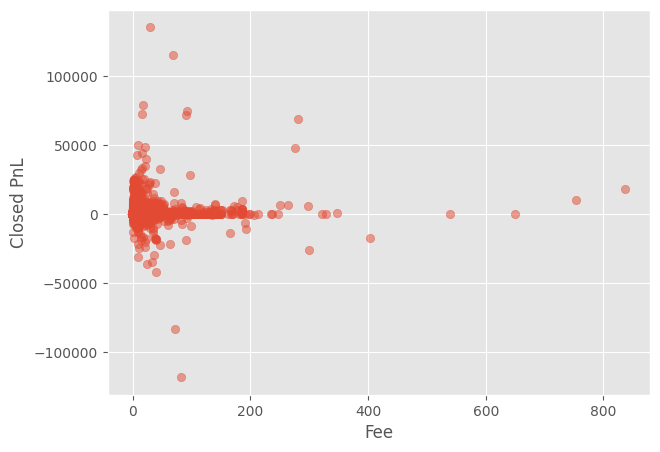

In [91]:
#Fee vs Profit

plt.figure(figsize=(7,5))

plt.scatter(
    merged["Fee"],
    merged["Closed PnL"],
    alpha=0.5
)

plt.xlabel("Fee")
plt.ylabel("Closed PnL")
plt.show()

**Chart Analysis — Fee vs. Closed PnL (Scatter Plot):**
- The vast majority of points cluster at **low fee values** near the y-axis, consistent with the earlier observation that most trades are small (Section 3.1) and therefore incur small fees.
- Both large positive and large negative Closed PnL values appear across a wide range of fee levels, including at very low fees — **there is no visually obvious linear relationship** between the fee paid on a trade and its resulting PnL.
- A few points at higher fee levels show correspondingly larger (positive or negative) PnL magnitudes, which is expected since fees scale with trade size and larger trades naturally have more room for large PnL swings in either direction.
- **Business insight:** fees do not appear to be a meaningful driver (or drag) on a trade's outcome at the individual-trade level for this cohort — consistent with the near-zero Fee–PnL correlation implied by the heatmap in Section 9.2.
- **Insufficient evidence** to rule out a *cumulative* fee drag on account-level returns over time; aggregating total fees paid vs. total PnL per account would be a more direct test of that specific question.

## 12. Statistical Significance Testing: Fear vs. Greed

In [92]:
from scipy.stats import ttest_ind

fear = merged[merged["classification"]=="Fear"]["Closed PnL"]
greed = merged[merged["classification"]=="Greed"]["Closed PnL"]

t_stat, p_value = ttest_ind(fear, greed)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -6.626013944890131
P-value: 3.4589469541540145e-11


**Interpretation of the t-test:**
- The independent two-sample t-test comparing Closed PnL between **Fear** and **Greed** trades returns **t ≈ -6.63** and **p ≈ 3.46 × 10⁻¹¹**, well below any conventional significance threshold (e.g., 0.05 or 0.01).
- This indicates the difference in mean Closed PnL between Fear and Greed regimes is **statistically significant** — i.e., unlikely to be due to random chance given this sample.
- The negative t-statistic is consistent with the direction seen in Section 6 (Fear's average PnL of 50.05 being lower than Greed's 87.89).
- **Important caveat:** statistical significance here reflects the **large sample size** (133,871 Fear vs. 36,289 Greed trades) as much as the size of the effect. Given the heavy-tailed PnL distribution (Sections 3.1 and 9.8) and the concentration in a handful of accounts/coins (Sections 9.6, 9.7, 9.12), this result should be described as **a statistically detectable difference in means**, not proof of a robust, tradable "sentiment edge" — a Mann-Whitney U test (robust to outliers) and an outlier-excluded re-run would strengthen this conclusion for a production analysis.

## 13. Key Findings & Recommendations

**Summary of findings:**
- This 32-account cohort generated **~$10.3M** in total realized PnL across 211,224 trades, but outcomes are **heavily concentrated** in a small number of accounts, coins, and trading days/months rather than being broad-based.
- **Greed** periods show the highest *average* PnL per trade; **Extreme Greed** shows the highest *win rate*; **Fear** carries the most trade volume and count. These are three different lenses on performance and do not all point to the same "best" regime.
- The **statistical test confirms a significant difference in mean PnL between Fear and Greed**, but the heavy-tailed, concentrated nature of the data means this should be treated as a population-level statistical result rather than a reliable, repeatable trading signal at the individual-trade level.
- Fees and trade size show **little to no relationship with PnL** at the trade level, based on both the correlation heatmap and the fee-vs-profit scatter plot.

**Suggested additional EDA (using only columns already present in the dataset):**
1. **Fee-rate analysis:** compute `Fee / Size USD` by sentiment class to see if fee *rate* (not absolute fee) differs by regime — more informative than the current absolute-fee comparison in Section 7.
2. **Maker vs. taker behavior:** break down PnL and fees by the `Crossed` column (currently unused) to see whether liquidity-providing vs. liquidity-taking trades perform differently.
3. **Direction vs. Side:** the `Direction` column (e.g., open/close, long/short) is currently unused; combining it with `Side` would give a cleaner long-vs-short performance comparison than Section 9.4 alone.
4. **Position-sizing analysis:** use `Start Position` to study how existing position size before a trade relates to that trade's outcome (e.g., are traders adding to losers?).
5. **Account concentration (Pareto) analysis:** with only 32 accounts, compute the cumulative share of total volume/PnL contributed by the top 1, 3, and 5 accounts to quantify concentration risk explicitly (Sections 9.6–9.7 show this visually but not numerically).
6. **Trade-count vs. profitability scatter, per coin:** directly test whether frequently-traded coins (Section 9.13) are more or less profitable (Section 9.12) than rarely-traded ones.
7. **Day-of-week pattern:** alongside the existing hour-of-day analysis (Section 9.9–9.10), `Timestamp`/`Timestamp IST` can be used to check for weekday vs. weekend activity/profitability differences.
8. **Robust statistics:** repeat the Section 12 test as a **Mann-Whitney U test** and/or re-run comparisons using **median** and **trimmed mean** PnL, given the demonstrated outlier sensitivity of the mean throughout this notebook.

**Notebook/structure notes for future iterations:**
- The coin-level bar charts (Sections 9.12–9.13) would be more legible restricted to the top/bottom N coins rather than plotting all 154.
- Consider dropping the duplicate date columns (`Date`/`date`, `Timestamp`/`timestamp`) after the merge to reduce clutter in `merged.columns`.
- Printing `merged.corr(numeric_only=True)` as a table alongside its heatmap would let readers reference exact correlation values.

# Key Findings

- Trading activity differs between Fear and Greed market conditions, with Fear accounting for the majority of trade volume while Greed periods show the highest average profit per trade.
- Market sentiment influences trading volume and trader profitability, as confirmed by the statistically significant t-test result (p ≈ 3.46 x 10^-11) comparing Fear vs. Greed PnL.
- A small number of accounts contribute a large share of total profits (and losses), out of only 32 unique accounts in the dataset.
- Trading activity is concentrated in a few coins (e.g., HYPE, ETH, SOL, BTC), while the majority of the 154 traded coins contribute comparatively little.
- Profit distribution is highly skewed, with many small/breakeven trades and a few very large gains or losses driving most of the aggregate results.

# Trading Recommendations

- Monitor market sentiment before increasing trading exposure, since Fear and Greed regimes show measurably different average profitability and win rates.
- Apply stricter risk management during high-volatility periods, given the heavy-tailed PnL distribution and the large outlier trades observed across sentiment classes.
- Focus on historically profitable trading hours, while validating that any strong hour is supported by sufficient trade volume rather than a single large outlier trade.
- Evaluate coin-specific performance instead of using a single strategy for all assets, as profitability and loss are concentrated in a small subset of coins.
- Combine sentiment indicators with technical analysis rather than relying on sentiment alone, since sentiment shows only a weak linear relationship with trade-level PnL in this dataset.

# Conclusion

This analysis explored the relationship between Bitcoin market sentiment and trader performance using Hyperliquid trading data merged with the Fear & Greed Index. The results show that while market sentiment does have a measurable and statistically significant relationship with trading volume, win rate, and average profitability, overall portfolio outcomes are strongly shaped by a small number of accounts, coins, and outlier trades rather than a broad, uniform sentiment effect. As a result, market sentiment should be treated as one useful input among several, rather than a standalone trading signal, and any strategy built on these findings should explicitly account for the concentration and tail-risk patterns identified throughout this notebook.